# Outcome-selection sensitivity analysis

This notebook evaluates whether expressing maximum and two-hour glucose as changes from `premeal_glucose` alters model performance or the participant phenotype recovered from the random-effect covariance. Peak duration and positive iAUC remain unchanged.

## Notebook flow

1. Derive `delta_max_glucose` and `delta_end_glucose` by subtracting `premeal_glucose` and construct one common complete-case sample.
2. Repeat the within-person temporal model comparison for the delta outcome set.
3. Fit absolute- and delta-outcome MMER-XGBoost models on the same free-living meal sample.
4. Compare covariance geometry, eigenspectra, matched loading axes/subspaces, participant scores, and Schur-complement structure.
5. Display the sensitivity tables and matched-axis diagnostic figure.

## Outputs

CSV files written to `Results/sensitivity_analyses/absolute_vs_relative_ppgr_metrics/`:

| File | Contents |
| --- | --- |
| `model_comparison_within_participant_CV_delta_outcomes.csv` | Outcome-specific and multivariate temporal-validation performance for the delta outcome set. |

Additional covariance and participant-agreement tables are displayed in the notebook; their CSV export block is commented out. The diagnostic figure is displayed with `save_path=None`.

## 1. Setup

Resolve project paths, import the shared modeling utilities, and construct a common complete-case dataset for both outcome specifications.

In [1]:
from pathlib import Path
import sys

# Find the project when launched from its root, Code/, or a notebook subfolder.
for PROJECT_ROOT in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    CODE_DIR = PROJECT_ROOT / "Code"
    if (CODE_DIR / "data_paths.py").is_file():
        break
else:
    raise FileNotFoundError("Open this notebook from within the project directory.")

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

# Shared defaults; override individual paths here if needed.
from data_paths import DATA_DIR, METADATA_PATH, MEAL_DATA_PATH, CGM_METRICS_PATH
FIGURES_DIR = PROJECT_ROOT / "Figures"
RESULTS_DIR = PROJECT_ROOT / "Results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import linear_sum_assignment
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
from mmer import MixedEffectEstimator

from utils import (
    LeavePercentTimeOut,
    build_design_mats,
    cols_for,
    ensure_cols,
    evaluate_models,
    load_and_prepare_data,
    make_tag,
    make_xgb,
    save_performance,
    show_performance,
)

In [3]:
meta_data, df_food, id_to_subject_key, clusters = load_and_prepare_data(
    METADATA_PATH,
    MEAL_DATA_PATH,
)

BASELINE_COLUMN = "premeal_glucose"
ABSOLUTE_OUTCOMES = [
    "max_glucose", "peak_duration", "end_glucose", "positive_iAUC",
]
DELTA_OUTCOMES = [
    "delta_max_glucose", "peak_duration",
    "delta_end_glucose", "positive_iAUC",
]
RANDOM_SLOPES = [
    "carb_eaten", "fat_eaten", "protein_eaten", "fiber_eaten",
]
EFFECTS = ["Intercept", "Carb", "Fat", "Protein", "Fiber"]

required_columns = [*ABSOLUTE_OUTCOMES, BASELINE_COLUMN]
missing_columns = sorted(set(required_columns) - set(df_food.columns))
if missing_columns:
    raise KeyError(f"Outcome-sensitivity analysis is missing: {missing_columns}")

# One common row set prevents missingness from confounding the comparison.
data = df_food.dropna(subset=required_columns).copy().reset_index(drop=True)
data["delta_max_glucose"] = data["max_glucose"] - data[BASELINE_COLUMN]
data["delta_end_glucose"] = data["end_glucose"] - data[BASELINE_COLUMN]
clusters = data["subject_key"].copy()
groups = clusters.to_numpy()

print(
    f"Prepared {len(data):,} complete meals from "
    f"{data['subject_key'].nunique():,} participants."
)
display(data[DELTA_OUTCOMES].describe().T)

data shape : (54987, 133)
Prepared 54,987 complete meals from 992 participants.


,count,mean,std,min,25%,50%,75%,max
delta_max_glucose,54987.0,24.449442,20.733677,0.000,9.000000,19.800000,34.380,189.540
peak_duration,54987.0,87.383291,37.305025,0.000,64.601175,103.229167,120.000,120.000
delta_end_glucose,54987.0,5.578568,18.398015,-125.804,-4.470100,4.320000,14.850,159.928
positive_iAUC,54987.0,1346.821722,1326.821507,0.000,324.000000,999.000000,1964.868,13651.200


In [4]:
data[DELTA_OUTCOMES].corr()

,delta_max_glucose,peak_duration,delta_end_glucose,positive_iAUC
delta_max_glucose,1.000000,0.565188,0.609437,0.947327
peak_duration,0.565188,1.000000,0.617072,0.608644
delta_end_glucose,0.609437,0.617072,1.000000,0.671400
positive_iAUC,0.947327,0.608644,0.671400,1.000000


## 2. Delta-outcome temporal model comparison

Repeat the five-fold, six-hour-embargo, within-participant temporal comparison from notebook 02. Only the delta outcome specification is run here; the absolute-outcome comparison remains in notebook 02.

In [5]:
models = [
    "LR", "LMMER_rand_int", "LMMER_full",
    "XGBoost", "MMER_XGBoost", "MMER_XGBoost_MI",
]
prediction_metrics = DELTA_OUTCOMES
run_tags = []
cv = LeavePercentTimeOut(
    n_splits=5, embargo=pd.Timedelta("6h"), random_state=42
)

for model_name in models:
    for std_mode in [True]:
        for interactions in [[False]]:
            for mundlak_corr in [False]:
                tag = make_tag(
                    model_name, std_mode, interactions, mundlak_corr
                )
                cmap = cols_for(tag, prediction_metrics)
                data = ensure_cols(data, cmap, tag)
                run_tags.append(tag)
                print(f"\nRunning cross-validation for {tag}...")

                pbar = tqdm(
                    cv.split(data, data["positive_iAUC"], groups=groups),
                    total=cv.get_n_splits(),
                    desc=f"{tag} CV",
                    unit="fold",
                    position=1,
                    ncols=100,
                    dynamic_ncols=False,
                )

                for fold, (train_idx, val_idx) in enumerate(pbar):
                    if model_name == "MMER_XGBoost":
                        (
                            X_train, X_val, _, _, y_train, y_val,
                            clusters_train, clusters_val, _, info_, _, _,
                        ) = build_design_mats(
                            data, train_idx, val_idx,
                            target_outcome=prediction_metrics,
                            apply_mundlak=mundlak_corr,
                            use_interactions=interactions,
                            population_z_scoring_features=True,
                            remove_std_meals_from_training=True,
                            remove_features=["demographics"],
                            random_slopes=RANDOM_SLOPES,
                            population_z_scoring_outcome=True,
                        )
                        model = MixedEffectEstimator(
                            make_xgb(), max_iter=50, slq_steps=40,
                            tol=1e-7, n_jobs=8,
                        )
                        groups_train_mmer = clusters_train.to_numpy().reshape(-1, 1)
                        y_train_mmer = np.asarray(y_train).reshape(len(y_train), -1)
                        result = model.fit(
                            X_train, y_train_mmer, groups_train_mmer,
                            random_slopes=([0, 1, 2, 3],),
                        )
                        groups_val_mmer = clusters_val.to_numpy().reshape(-1, 1)
                        y_pred_full = result.predict(
                            X_val, groups=groups_val_mmer
                        )
                        y_pred_fixed = result.fixed_effects_model.predict(X_val)

                    elif model_name == "MMER_XGBoost_MI":
                        (
                            X_train, X_val, _, _, y_train, y_val,
                            clusters_train, clusters_val, _, info_, _, _,
                        ) = build_design_mats(
                            data, train_idx, val_idx,
                            target_outcome=prediction_metrics,
                            apply_mundlak=mundlak_corr,
                            use_interactions=interactions,
                            population_z_scoring_features=True,
                            remove_std_meals_from_training=True,
                            remove_features=["demographics"],
                            random_slopes=RANDOM_SLOPES,
                            population_z_scoring_outcome=True,
                        )
                        model = MixedEffectEstimator(
                            make_xgb(), max_iter=50, slq_steps=40,
                            tol=1e-7, n_jobs=8,
                        )
                        groups_train_mmer = clusters_train.to_numpy().reshape(-1, 1)
                        y_train_mmer = np.asarray(y_train).reshape(len(y_train), -1)
                        result = model.fit(
                            X_train, y_train_mmer, groups_train_mmer
                        )
                        groups_val_mmer = clusters_val.to_numpy().reshape(-1, 1)
                        y_pred_full = result.predict(
                            X_val, groups=groups_val_mmer
                        )
                        y_pred_fixed = result.fixed_effects_model.predict(X_val)

                    elif model_name == "LR":
                        (
                            X_train, X_val, _, _, y_train, y_val,
                            _, _, _, info_, _, _,
                        ) = build_design_mats(
                            data, train_idx, val_idx,
                            target_outcome=prediction_metrics,
                            apply_mundlak=mundlak_corr,
                            use_interactions=interactions,
                            population_z_scoring_features=True,
                            remove_std_meals_from_training=True,
                            remove_features=["demographics"],
                            random_slopes=RANDOM_SLOPES,
                            population_z_scoring_outcome=True,
                            imputation="participant_mean",
                        )
                        fitted_model = LinearRegression().fit(X_train, y_train)
                        y_pred_full = fitted_model.predict(X_val)
                        y_pred_fixed = y_pred_full

                    elif model_name == "LMMER_full":
                        (
                            X_train, X_val, _, _, y_train, y_val,
                            clusters_train, clusters_val, _, info_, _, _,
                        ) = build_design_mats(
                            data, train_idx, val_idx,
                            target_outcome=prediction_metrics,
                            apply_mundlak=mundlak_corr,
                            use_interactions=interactions,
                            population_z_scoring_features=True,
                            remove_std_meals_from_training=True,
                            remove_features=["demographics"],
                            random_slopes=RANDOM_SLOPES,
                            population_z_scoring_outcome=True,
                            imputation="participant_mean",
                        )
                        model = MixedEffectEstimator(
                            LinearRegression(), max_iter=50, slq_steps=40,
                            tol=1e-7, n_jobs=8,
                        )
                        groups_train_mmer = clusters_train.to_numpy().reshape(-1, 1)
                        y_train_mmer = np.asarray(y_train).reshape(len(y_train), -1)
                        result = model.fit(
                            X_train, y_train_mmer, groups_train_mmer,
                            random_slopes=([0, 1, 2, 3],),
                        )
                        groups_val_mmer = clusters_val.to_numpy().reshape(-1, 1)
                        y_pred_full = result.predict(
                            X_val, groups=groups_val_mmer
                        )
                        y_pred_fixed = result.fixed_effects_model.predict(X_val)

                    elif model_name == "LMMER_rand_int":
                        (
                            X_train, X_val, _, _, y_train, y_val,
                            clusters_train, clusters_val, _, info_, _, _,
                        ) = build_design_mats(
                            data, train_idx, val_idx,
                            target_outcome=prediction_metrics,
                            apply_mundlak=mundlak_corr,
                            use_interactions=interactions,
                            population_z_scoring_features=True,
                            remove_std_meals_from_training=True,
                            remove_features=["demographics"],
                            random_slopes=RANDOM_SLOPES,
                            population_z_scoring_outcome=True,
                            imputation="participant_mean",
                        )
                        model = MixedEffectEstimator(
                            LinearRegression(), max_iter=50, slq_steps=40,
                            tol=1e-7, n_jobs=8,
                        )
                        groups_train_mmer = clusters_train.to_numpy().reshape(-1, 1)
                        y_train_mmer = np.asarray(y_train).reshape(len(y_train), -1)
                        result = model.fit(
                            X_train, y_train_mmer, groups_train_mmer
                        )
                        groups_val_mmer = clusters_val.to_numpy().reshape(-1, 1)
                        y_pred_full = result.predict(
                            X_val, groups=groups_val_mmer
                        )
                        y_pred_fixed = result.fixed_effects_model.predict(X_val)

                    elif model_name == "XGBoost":
                        (
                            X_train, X_val, _, _, y_train, y_val,
                            _, _, _, info_, _, _,
                        ) = build_design_mats(
                            data, train_idx, val_idx,
                            target_outcome=prediction_metrics,
                            apply_mundlak=mundlak_corr,
                            use_interactions=interactions,
                            population_z_scoring_features=True,
                            remove_std_meals_from_training=True,
                            remove_features=["demographics"],
                            random_slopes=RANDOM_SLOPES,
                            population_z_scoring_outcome=True,
                        )
                        fitted_model = make_xgb().fit(X_train, y_train)
                        y_pred_full = fitted_model.predict(X_val)
                        y_pred_fixed = y_pred_full

                    n_validation = len(val_idx)
                    y_val_z = np.asarray(y_val).reshape(n_validation, -1)
                    y_pred_z = np.asarray(y_pred_full).reshape(n_validation, -1)
                    y_fixed_z = np.asarray(y_pred_fixed).reshape(n_validation, -1)

                    # Back-transform fold predictions for interpretable metrics.
                    y_mean = np.asarray(info_["outcome_mean"])
                    y_std = np.asarray(info_["outcome_std"])
                    y_val_original = y_val_z * y_std + y_mean
                    y_pred_original = y_pred_z * y_std + y_mean
                    y_fixed_original = y_fixed_z * y_std + y_mean

                    validation_labels = data.index[val_idx]
                    data.loc[validation_labels, cmap["true_z"]] = y_val_z
                    data.loc[validation_labels, cmap["pred_z"]] = y_pred_z
                    data.loc[validation_labels, cmap["true"]] = y_val_original
                    data.loc[validation_labels, cmap["pred"]] = y_pred_original
                    data.loc[validation_labels, cmap["pred_fixed_z"]] = y_fixed_z
                    data.loc[validation_labels, cmap["pred_fixed"]] = y_fixed_original
                    data.loc[validation_labels, f"{tag}__fold"] = fold


Running cross-validation for LR...



LR CV: 100%|████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.51s/fold]



Running cross-validation for LMMER_rand_int...



Converged: tolerance reached!:  42%|████▏     | 21/50 00:10                 | 0/5 [00:00<?, ?fold/s]

Converged: tolerance reached!:  42%|████▏     | 21/50 00:10             5 [00:11<00:47, 11.85s/fold]

Converged: tolerance reached!:  40%|████      | 20/50 00:09             5 [00:24<00:36, 12.22s/fold]

Converged: tolerance reached!:  44%|████▍     | 22/50 00:10             5 [00:35<00:23, 11.81s/fold]

Converged: tolerance reached!:  42%|████▏     | 21/50 00:10             5 [00:47<00:11, 11.93s/fold]

LMMER_rand_int CV: 100%|████████████████████████████████████████████| 5/5 [00:59<00:00, 11.88s/fold]



Running cross-validation for LMMER_full...


...


XGBoost CV: 100%|███████████████████████████████████████████████████| 5/5 [01:29<00:00, 17.82s/fold]



Running cross-validation for MMER_XGBoost...



Finished: no further improvement!:  42%|████▏     | 21/50 06:05             | 0/5 [00:00<?, ?fold/s]

Finished: no further improvement!:  40%|████      | 20/50 05:50          [06:24<25:39, 384.85s/fold]

Finished: no further improvement!:  48%|████▊     | 24/50 06:52          [12:34<18:48, 376.08s/fold]

Finished: no further improvement!:  56%|█████▌    | 28/50 07:56          [19:45<13:22, 401.22s/fold]

Finished: no further improvement!:  32%|███▏      | 16/50 04:45          [28:01<07:18, 438.53s/fold]

MMER_XGBoost CV: 100%|█████████████████████████████████████████████| 5/5 [33:05<00:00, 397.20s/fold]



Running cross-validation for MMER_XGBoost_MI...



Finished: no further improvement!:  12%|█▏        | 6/50 01:43              | 0/5 [00:00<?, ?fold/s]

Finished: no further improvement!:  34%|███▍      | 17/50 04:49          [02:03<08:12, 123.23s/fold]

Finished: no further improvement!:  22%|██▏       | 11/50 03:05          [07:12<11:38, 232.75s/fold]

Finished: no further improvement!:  16%|█▌        | 8/50 02:16         5 [10:36<07:19, 219.69s/fold]

Finished: no further improvement!:  14%|█▍        | 7/50 02:00         5 [13:12<03:14, 194.42s/fold]

MMER_XGBoost_MI CV: 100%|██████████████████████████████████████████| 5/5 [15:32<00:00, 186.51s/fold]


## 3. Delta-outcome performance table

Summarize outcome-specific and uniform-average multivariate performance using the out-of-fold predictions above.

In [6]:
delta_performance = evaluate_models(data, run_tags, DELTA_OUTCOMES)
delta_performance_tables = show_performance(
    delta_performance, DELTA_OUTCOMES)

delta_metric_order = DELTA_OUTCOMES + ["Multivariate (uniform R²)"]
delta_performance_table = save_performance(
    delta_performance,
    delta_metric_order,
    RESULTS_DIR / "sensitivity_analyses/absolute_vs_relative_ppgr_metrics/model_comparison_within_participant_CV_delta_outcomes.csv",
)


── all meals (R² | Pearson r) ──
Model                          n   LMMER_full LMMER_rand_int           LR MMER_XGBoost MMER_XGBoost_MI      XGBoost
Metric                                                                                                             
delta_max_glucose          54987  0.36 | 0.60    0.34 | 0.59  0.25 | 0.50  0.52 | 0.72     0.51 | 0.72  0.44 | 0.66
peak_duration              54987  0.34 | 0.58    0.33 | 0.58  0.30 | 0.55  0.44 | 0.67     0.44 | 0.67  0.43 | 0.65
delta_end_glucose          54987  0.41 | 0.64    0.40 | 0.63  0.34 | 0.58  0.46 | 0.68     0.46 | 0.68  0.41 | 0.64
positive_iAUC              54987  0.36 | 0.60    0.34 | 0.59  0.25 | 0.50  0.50 | 0.70     0.49 | 0.70  0.42 | 0.65
Multivariate (uniform R²)  54987         0.37           0.35         0.28         0.48            0.47         0.42

── standardized (R² | Pearson r) ──
Model                         n    LMMER_full LMMER_rand_int            LR MMER_XGBoost MMER_XGBoost_MI      XGBoost


## 4. Full-model covariance fits

Fit the same MMER-XGBoost random-intercept/random-slope specification to the absolute and delta outcome sets, using the same free-living meals from the common complete-case sample.

In [7]:
def covariance_pca(G, labels, blups=None, cluster_mapping=None):
    """Eigendecompose G using its non-negative spectrum for variance shares."""
    G = np.asarray(G, dtype=float)
    G = 0.5 * (G + G.T)
    eigenvalues, eigenvectors = np.linalg.eigh(G)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    nonnegative = np.clip(eigenvalues, 0.0, None)
    if nonnegative.sum() <= 0:
        raise ValueError("G has no positive variance.")
    variance_explained = pd.Series(
        nonnegative / nonnegative.sum(),
        index=[f"PC{i + 1}" for i in range(len(eigenvalues))],
        name="variance_explained",
    )
    loadings = pd.DataFrame(
        eigenvectors, index=labels, columns=variance_explained.index
    )

    scores = None
    if blups is not None:
        centered = blups.to_numpy(dtype=float) - blups.to_numpy(dtype=float).mean(axis=0)
        scores = pd.DataFrame(
            centered @ eigenvectors,
            index=blups.index,
            columns=variance_explained.index,
        )
        if cluster_mapping is not None:
            scores.index.name = "cluster"
            scores = scores.reset_index().merge(
                cluster_mapping, on="cluster", how="inner"
            )
    return loadings, variance_explained, scores


def fit_full_outcome_specification(frame, outcomes, specification_name):
    """Fit one full-data model and return G, BLUPs, PCs, and design metadata."""
    print(f"\nFitting {specification_name}: {outcomes}")
    (
        X_fit, _, Z_fit, _, y_fit, _, clusters_fit, _,
        cluster_mapping_fit, info_fit, train_dataframe_fit, _,
    ) = build_design_mats(
        frame,
        full_train=True,
        target_outcome=outcomes,
        apply_mundlak=False,
        use_interactions=[False],
        population_z_scoring_features=True,
        remove_std_meals_from_training=True,
        remove_features=["demographics"],
        random_slopes=RANDOM_SLOPES,
        population_z_scoring_outcome=True,
    )
    groups_fit = clusters_fit.to_numpy().reshape(-1, 1)
    y_fit_mmer = np.asarray(y_fit).reshape(len(y_fit), -1)
    model = MixedEffectEstimator(
        make_xgb(njobs=8),
        max_iter=50,
        slq_steps=40,
        tol=1e-7,
        n_jobs=4,
    )
    fit_result = model.fit(
        X_fit, y_fit_mmer, groups_fit, random_slopes=([0, 1, 2, 3],)
    )
    blups_fit = fit_result.blups(
        X=X_fit, y=y_fit_mmer, groups=groups_fit, group_idx=0
    )
    labels_fit = [
        f"{outcome}|{effect}"
        for outcome in outcomes
        for effect in EFFECTS
    ]
    blups_fit.columns = labels_fit
    G_fit = np.asarray(fit_result.G[0], dtype=float)
    loadings_fit, variance_fit, scores_fit = covariance_pca(
        G_fit, labels_fit, blups_fit, cluster_mapping_fit
    )
    return {
        "name": specification_name,
        "outcomes": list(outcomes),
        "labels": labels_fit,
        "X_train": X_fit,
        "Z_train": Z_fit,
        "y_train": y_fit_mmer,
        "groups": groups_fit,
        "cluster_mapping": cluster_mapping_fit,
        "info": info_fit,
        "train_dataframe": train_dataframe_fit,
        "model": model,
        "fit_result": fit_result,
        "G": G_fit,
        "blups": blups_fit,
        "loadings": loadings_fit,
        "variance_explained": variance_fit,
        "scores": scores_fit,
    }


sensitivity_original = fit_full_outcome_specification(
    data, ABSOLUTE_OUTCOMES, "absolute outcomes"
)
sensitivity_delta = fit_full_outcome_specification(
    data, DELTA_OUTCOMES, "premeal-adjusted outcomes"
)

# Confirm that only the target matrices differ between the two fits.
np.testing.assert_allclose(
    sensitivity_original["X_train"],
    sensitivity_delta["X_train"],
    equal_nan=True,
)
np.testing.assert_allclose(
    sensitivity_original["Z_train"],
    sensitivity_delta["Z_train"],
    equal_nan=True,
)
np.testing.assert_array_equal(
    sensitivity_original["groups"], sensitivity_delta["groups"]
)


Fitting absolute outcomes: ['max_glucose', 'peak_duration', 'end_glucose', 'positive_iAUC']


Finished: no further improvement!:  66%|██████▌   | 33/50 08:08         



Fitting premeal-adjusted outcomes: ['delta_max_glucose', 'peak_duration', 'delta_end_glucose', 'positive_iAUC']


Finished: no further improvement!:  42%|████▏     | 21/50 05:10         


## 5. Covariance and phenotype sensitivity

Compare spectra and correlation geometry before examining individual PC axes. PC axes are matched one-to-one by maximum absolute cosine similarity and sign-aligned. This avoids mistaking arbitrary eigenvector signs or reordered axes for substantive disagreement.

In [8]:
INTERCEPT_SUFFIX = "|Intercept"


def spectrum(G, clip=True):
    """Descending eigenvalues, variance shares, cumulative shares, and d_eff."""
    G = np.asarray(G, dtype=float)
    G = 0.5 * (G + G.T)
    eigenvalues = np.linalg.eigvalsh(G)[::-1]
    values = np.clip(eigenvalues, 0.0, None) if clip else eigenvalues
    total = values.sum()
    squared_total = np.square(values).sum()
    if not np.isfinite(total) or total <= 0 or squared_total <= 0:
        raise ValueError("The covariance spectrum has no positive variance.")
    shares = values / total
    return {
        "eigenvalues": values,
        "raw_eigenvalues": eigenvalues,
        "variance_share": shares,
        "cumulative_share": np.cumsum(shares),
        "d_eff": total ** 2 / squared_total,
        "trace": total,
        "raw_trace": np.trace(G),
    }


def eigenvectors(G, clip=True):
    G = np.asarray(G, dtype=float)
    G = 0.5 * (G + G.T)
    values, vectors = np.linalg.eigh(G)
    order = np.argsort(values)[::-1]
    values, vectors = values[order], vectors[:, order]
    if clip:
        values = np.clip(values, 0.0, None)
    return values, vectors


def subspace_agreement(V_a, V_b, k):
    """Principal-angle cosines between two leading k-dimensional subspaces."""
    if k < 1 or k > min(V_a.shape[1], V_b.shape[1]):
        raise ValueError("k is outside the available subspace dimensions.")
    cosines = np.linalg.svd(V_a[:, :k].T @ V_b[:, :k], compute_uv=False)
    return np.clip(cosines, 0.0, 1.0)


def to_correlation(G):
    G = np.asarray(G, dtype=float)
    diagonal = np.diag(G)
    if np.any(diagonal <= 0):
        raise ValueError("All covariance diagonal entries must be positive.")
    sd = np.sqrt(diagonal)
    return G / np.outer(sd, sd)


def icc_paired(x, y):
    """ICC(3,1) consistency and ICC(2,1) agreement for paired scores."""
    paired = np.column_stack([np.asarray(x, float), np.asarray(y, float)])
    paired = paired[np.isfinite(paired).all(axis=1)]
    n, k = paired.shape
    if n < 3:
        return np.nan, np.nan
    grand = paired.mean()
    row_means = paired.mean(axis=1)
    column_means = paired.mean(axis=0)
    ms_rows = k * np.square(row_means - grand).sum() / (n - 1)
    ms_columns = n * np.square(column_means - grand).sum() / (k - 1)
    residual = paired - row_means[:, None] - column_means[None, :] + grand
    ms_error = np.square(residual).sum() / ((n - 1) * (k - 1))
    denominator_consistency = ms_rows + (k - 1) * ms_error
    denominator_agreement = (
        denominator_consistency + k * (ms_columns - ms_error) / n
    )
    icc31 = (
        (ms_rows - ms_error) / denominator_consistency
        if denominator_consistency != 0 else np.nan
    )
    icc21 = (
        (ms_rows - ms_error) / denominator_agreement
        if denominator_agreement != 0 else np.nan
    )
    return icc31, icc21


def schur_complement(G, labels, rcond=1e-12):
    """Slope covariance conditional on the intercept block."""
    G = np.asarray(G, dtype=float)
    G = 0.5 * (G + G.T)
    is_intercept = np.array([label.endswith(INTERCEPT_SUFFIX) for label in labels])
    intercept_indices = np.flatnonzero(is_intercept)
    slope_indices = np.flatnonzero(~is_intercept)
    G_ii = G[np.ix_(intercept_indices, intercept_indices)]
    G_si = G[np.ix_(slope_indices, intercept_indices)]
    G_is = G[np.ix_(intercept_indices, slope_indices)]
    G_ss = G[np.ix_(slope_indices, slope_indices)]
    conditioned = G_ss - G_si @ np.linalg.pinv(
        G_ii, rcond=rcond, hermitian=True
    ) @ G_is
    return {
        "conditioned": 0.5 * (conditioned + conditioned.T),
        "slope_labels": [labels[index] for index in slope_indices],
        "condition_number": np.linalg.cond(G_ii),
        "intercept_trace_share": np.trace(G_ii) / np.trace(G),
    }


def orient(vector, labels, keyword="Carb"):
    """Sign-pin a vector so its dominant keyword loading is positive."""
    vector = np.asarray(vector, dtype=float)
    mask = np.array([keyword in label for label in labels])
    reference = vector[mask] if mask.any() else vector
    pivot = reference[np.argmax(np.abs(reference))]
    return vector * (1.0 if pivot >= 0 else -1.0)


def match_pc_axes(V_reference, V_alternative):
    """Globally match PC columns and align alternative signs to reference."""
    cosine = (V_reference.T @ V_alternative) / np.outer(
        np.linalg.norm(V_reference, axis=0),
        np.linalg.norm(V_alternative, axis=0),
    )
    reference_axes, alternative_axes = linear_sum_assignment(-np.abs(cosine))
    mapping = dict(zip(reference_axes, alternative_axes))
    if len(mapping) != V_reference.shape[1]:
        raise RuntimeError("PC matching is incomplete.")
    aligned = np.empty_like(V_reference)
    signs = np.ones(V_reference.shape[1])
    for reference_axis in range(V_reference.shape[1]):
        alternative_axis = mapping[reference_axis]
        signs[reference_axis] = (
            1.0 if cosine[reference_axis, alternative_axis] >= 0 else -1.0
        )
        aligned[:, reference_axis] = (
            signs[reference_axis] * V_alternative[:, alternative_axis]
        )
    return aligned, mapping, signs, cosine


def align_participant_scores(reference, alternative, mapping, signs):
    """Return one row per participant with matched, sign-aligned PC scores."""
    reference_scores = (
        reference["scores"].drop_duplicates("subject_key").set_index("subject_key")
    )
    alternative_scores = (
        alternative["scores"].drop_duplicates("subject_key").set_index("subject_key")
    )
    common = reference_scores.index.intersection(
        alternative_scores.index, sort=False
    )
    aligned = pd.DataFrame(index=common)
    for reference_axis in range(len(mapping)):
        reference_pc = f"PC{reference_axis + 1}"
        alternative_pc = f"PC{mapping[reference_axis] + 1}"
        aligned[f"{reference_pc}_original"] = (
            reference_scores.loc[common, reference_pc].to_numpy(float)
        )
        aligned[f"{reference_pc}_delta_aligned"] = (
            signs[reference_axis]
            * alternative_scores.loc[common, alternative_pc].to_numpy(float)
        )
        aligned[f"{reference_pc}_difference"] = (
            aligned[f"{reference_pc}_delta_aligned"]
            - aligned[f"{reference_pc}_original"]
        )
    aligned.index.name = "subject_key"
    return aligned.reset_index()

### 5.1 Global covariance, axes, and participant agreement

Exact invariance would require negligible covariance differences, loading/subspace cosines near 1, and participant-score correlations and ICCs near 1. Because subtracting premeal glucose changes two outcomes and each specification is standardized independently, agreement is an empirical result rather than a mathematical identity.


In [9]:
# Match outcome labels and covariance order to the absolute-outcome model.
labels = list(sensitivity_original["labels"])
outcome_alias = {
    "delta_max_glucose": "max_glucose",
    "delta_end_glucose": "end_glucose",
}
delta_canonical_labels = [
    f"{outcome_alias.get(label.split('|', 1)[0], label.split('|', 1)[0])}"
    f"|{label.split('|', 1)[1]}"
    for label in sensitivity_delta["labels"]
]
if len(set(delta_canonical_labels)) != len(delta_canonical_labels):
    raise ValueError("Canonical delta labels are not unique.")
if set(delta_canonical_labels) != set(labels):
    raise ValueError("Absolute and delta random-effect coordinates do not match.")
delta_reindex = [delta_canonical_labels.index(label) for label in labels]

G_absolute = np.asarray(sensitivity_original["G"], float)
G_delta = np.asarray(sensitivity_delta["G"], float)[
    np.ix_(delta_reindex, delta_reindex)
]

# Use the fitted loading matrices so matched axes and score columns stay synchronized.
V_absolute = sensitivity_original["loadings"].loc[labels].to_numpy(float)
delta_loadings = sensitivity_delta["loadings"].copy()
delta_loadings.index = delta_canonical_labels
V_delta = delta_loadings.loc[labels].to_numpy(float)
V_delta_aligned, pc_mapping, pc_signs, pc_cosines = match_pc_axes(
    V_absolute, V_delta
)

participant_scores = align_participant_scores(
    sensitivity_original, sensitivity_delta, pc_mapping, pc_signs
)
absolute_variance = sensitivity_original["variance_explained"].to_numpy(float)
delta_variance = sensitivity_delta["variance_explained"].to_numpy(float)

pc_axis_matching = pd.DataFrame([
    {
        "reference_pc": f"PC{reference_axis + 1}",
        "matched_delta_pc": f"PC{pc_mapping[reference_axis] + 1}",
        "sign_applied_to_delta": pc_signs[reference_axis],
        "absolute_loading_cosine": abs(
            pc_cosines[reference_axis, pc_mapping[reference_axis]]
        ),
        "variance_share_absolute": absolute_variance[reference_axis],
        "variance_share_delta_matched": delta_variance[pc_mapping[reference_axis]],
        "max_absolute_loading_difference": np.max(np.abs(
            V_delta_aligned[:, reference_axis] - V_absolute[:, reference_axis]
        )),
    }
    for reference_axis in range(V_absolute.shape[1])
])

# 1. Eigenspectrum and effective dimensionality.
spec_absolute = spectrum(G_absolute)
spec_delta = spectrum(G_delta)
n_spectrum_axes = min(6, len(labels))
spectrum_table = pd.DataFrame({
    "axis": [f"PC{i + 1}" for i in range(n_spectrum_axes)],
    "share_absolute": spec_absolute["variance_share"][:n_spectrum_axes],
    "share_delta": spec_delta["variance_share"][:n_spectrum_axes],
    "cumulative_absolute": spec_absolute["cumulative_share"][:n_spectrum_axes],
    "cumulative_delta": spec_delta["cumulative_share"][:n_spectrum_axes],
})
dimensionality_table = pd.DataFrame({
    "specification": ["absolute", "delta"],
    "effective_dimension": [spec_absolute["d_eff"], spec_delta["d_eff"]],
    "positive_spectrum_trace": [spec_absolute["trace"], spec_delta["trace"]],
    "raw_covariance_trace": [spec_absolute["raw_trace"], spec_delta["raw_trace"]],
})
display(dimensionality_table.round(4))
display(spectrum_table.round(4))

# 2. Leading-subspace agreement is invariant to sign and within-subspace rotation.
subspace_table = pd.DataFrame([
    {
        "subspace_dimension": k,
        "minimum_principal_cosine": subspace_agreement(
            V_absolute, V_delta, k
        ).min(),
        "mean_principal_cosine": subspace_agreement(
            V_absolute, V_delta, k
        ).mean(),
    }
    for k in range(1, min(3, len(labels)) + 1)
])
display(subspace_table.round(4))

# 3. Separate covariance-scale changes from correlation-geometry changes.
R_absolute = to_correlation(G_absolute)
R_delta = to_correlation(G_delta)
covariance_triangle = np.triu_indices_from(G_absolute)
correlation_triangle = np.triu_indices_from(G_absolute, k=1)
intercept_indices = np.array([
    i for i, label in enumerate(labels) if label.endswith(INTERCEPT_SUFFIX)
])

geometry_summary = pd.Series({
    "covariance_upper_triangle_r": np.corrcoef(
        G_absolute[covariance_triangle], G_delta[covariance_triangle]
    )[0, 1],
    "covariance_relative_frobenius": (
        np.linalg.norm(G_delta - G_absolute, "fro")
        / np.linalg.norm(G_absolute, "fro")
    ),
    "covariance_max_absolute_difference": np.max(
        np.abs(G_delta - G_absolute)
    ),
    "correlation_upper_triangle_r": np.corrcoef(
        R_absolute[correlation_triangle], R_delta[correlation_triangle]
    )[0, 1],
    "correlation_relative_frobenius": (
        np.linalg.norm(R_delta - R_absolute, "fro")
        / np.linalg.norm(R_absolute, "fro")
    ),
    "correlation_max_absolute_difference": np.max(
        np.abs(R_delta - R_absolute)
    ),
    "intercept_variance_share_absolute": (
        np.trace(G_absolute[np.ix_(intercept_indices, intercept_indices)])
        / np.trace(G_absolute)
    ),
    "intercept_variance_share_delta": (
        np.trace(G_delta[np.ix_(intercept_indices, intercept_indices)])
        / np.trace(G_delta)
    ),
}, name="value")
display(geometry_summary.to_frame().round(4))

# 4. Coordinate SDs are comparable here in independently standardized outcome units.
sd_absolute = np.sqrt(np.clip(np.diag(G_absolute), 0.0, None))
sd_delta = np.sqrt(np.clip(np.diag(G_delta), 0.0, None))
coordinate_table = pd.DataFrame({
    "coordinate": labels,
    "sd_absolute": sd_absolute,
    "sd_delta": sd_delta,
    "ratio_delta_over_absolute": np.divide(
        sd_delta,
        sd_absolute,
        out=np.full_like(sd_delta, np.nan),
        where=sd_absolute > 0,
    ),
})
display(
    coordinate_table.sort_values("ratio_delta_over_absolute").round(4)
)

# 5. Report aligned loadings for the two leading matched axes.
loading_table = pd.DataFrame(index=labels)
for axis, keyword in zip(range(min(2, len(labels))), ["Intercept", "Carb"]):
    oriented_reference = orient(V_absolute[:, axis], labels, keyword)
    display_sign = (
        1.0 if np.dot(oriented_reference, V_absolute[:, axis]) >= 0 else -1.0
    )
    oriented_delta = display_sign * V_delta_aligned[:, axis]
    loading_table[f"PC{axis + 1}_absolute"] = oriented_reference
    loading_table[f"PC{axis + 1}_delta_aligned"] = oriented_delta
    loading_table[f"PC{axis + 1}_difference"] = (
        oriented_delta - oriented_reference
    )
display(
    loading_table.reindex(
        loading_table["PC1_absolute"].abs().sort_values(ascending=False).index
    ).head(12).round(3)
)
display(pc_axis_matching.head(6).round(4))


# 6. Participant-score agreement, including the quartiles used downstream.
agreement_rows = []
for axis in range(min(2, len(labels))):
    pc = f"PC{axis + 1}"
    paired = participant_scores[
        [f"{pc}_original", f"{pc}_delta_aligned"]
    ].dropna()
    absolute_score = paired.iloc[:, 0].to_numpy(float)
    delta_score = paired.iloc[:, 1].to_numpy(float)
    icc31, icc21 = icc_paired(absolute_score, delta_score)

    # Ranking first makes quartiles deterministic even when score values tie.
    q_absolute = pd.qcut(
        pd.Series(absolute_score).rank(method="first"), 4, labels=False
    ).to_numpy()
    q_delta = pd.qcut(
        pd.Series(delta_score).rank(method="first"), 4, labels=False
    ).to_numpy()
    reference_extremes = np.isin(q_absolute, [0, 3])
    agreement_rows.append({
        "axis": pc,
        "n_participants": len(paired),
        "pearson_r": np.corrcoef(absolute_score, delta_score)[0, 1],
        "spearman_r": pd.Series(absolute_score).corr(
            pd.Series(delta_score), method="spearman"
        ),
        "icc_3_1_consistency": icc31,
        "icc_2_1_absolute": icc21,
        "rmse": np.sqrt(np.mean(np.square(delta_score - absolute_score))),
        "same_quartile_pct": 100 * np.mean(q_absolute == q_delta),
        "extreme_quartile_flips": int(
            np.sum(np.abs(q_absolute - q_delta) == 3)
        ),
        "reference_extreme_membership_preserved_pct": 100 * np.mean(
            np.isin(q_delta[reference_extremes], [0, 3])
        ),
        "reference_extreme_quartile_preserved_pct": 100 * np.mean(
            q_absolute[reference_extremes] == q_delta[reference_extremes]
        ),
    })
participant_agreement = pd.DataFrame(agreement_rows)
display(participant_agreement.round(4))


# 7. Compare random-slope structure after conditioning on intercepts.
schur_absolute = schur_complement(G_absolute, labels)
schur_delta = schur_complement(G_delta, labels)
spec_schur_absolute = spectrum(schur_absolute["conditioned"])
spec_schur_delta = spectrum(schur_delta["conditioned"])
_, W_absolute = eigenvectors(schur_absolute["conditioned"])
_, W_delta = eigenvectors(schur_delta["conditioned"])
W_delta_aligned, schur_mapping, schur_signs, schur_cosines = match_pc_axes(
    W_absolute, W_delta
)

schur_summary = pd.DataFrame({
    "effective_dimension": [
        spec_schur_absolute["d_eff"], spec_schur_delta["d_eff"]
    ],
    "PCc1_share": [
        spec_schur_absolute["variance_share"][0],
        spec_schur_delta["variance_share"][0],
    ],
    "PCc2_share": [
        spec_schur_absolute["variance_share"][1],
        spec_schur_delta["variance_share"][1],
    ],
    "intercept_block_condition_number": [
        schur_absolute["condition_number"], schur_delta["condition_number"]
    ],
    "intercept_trace_share": [
        schur_absolute["intercept_trace_share"],
        schur_delta["intercept_trace_share"],
    ],
}, index=["absolute", "delta"])
display(schur_summary.round(4))

schur_axis_matching = pd.DataFrame([
    {
        "reference_axis": f"PCc{axis + 1}",
        "matched_delta_axis": f"PCc{schur_mapping[axis] + 1}",
        "absolute_loading_cosine": abs(
            schur_cosines[axis, schur_mapping[axis]]
        ),
    }
    for axis in range(W_absolute.shape[1])
])
schur_subspace_table = pd.DataFrame([
    {
        "subspace_dimension": k,
        "minimum_principal_cosine": subspace_agreement(
            W_absolute, W_delta, k
        ).min(),
        "mean_principal_cosine": subspace_agreement(
            W_absolute, W_delta, k
        ).mean(),
    }
    for k in range(1, min(3, W_absolute.shape[1]) + 1)
])
display(schur_axis_matching.head(3).round(4))
display(schur_subspace_table.round(4))

slope_labels = schur_absolute["slope_labels"]
schur_reference_pc1 = orient(W_absolute[:, 0], slope_labels, "Carb")
schur_display_sign = (
    1.0 if np.dot(schur_reference_pc1, W_absolute[:, 0]) >= 0 else -1.0
)
schur_delta_pc1 = schur_display_sign * W_delta_aligned[:, 0]
schur_loading_table = pd.DataFrame({
    "PCc1_absolute": schur_reference_pc1,
    "PCc1_delta_aligned": schur_delta_pc1,
    "PCc1_difference": schur_delta_pc1 - schur_reference_pc1,
}, index=slope_labels)
display(
    schur_loading_table.reindex(
        schur_loading_table["PCc1_absolute"].abs()
        .sort_values(ascending=False).index
    ).head(8).round(3)
)

sensitivity_comparison = {
    "labels": labels,
    "G_absolute": G_absolute,
    "G_delta": G_delta,
    "reference_loadings": pd.DataFrame(
        V_absolute, index=labels,
        columns=[f"PC{i + 1}" for i in range(V_absolute.shape[1])],
    ),
    "alternative_loadings_aligned": pd.DataFrame(
        V_delta_aligned, index=labels,
        columns=[f"PC{i + 1}" for i in range(V_absolute.shape[1])],
    ),
    "participant_scores": participant_scores,
    "axis_matching": pc_axis_matching,
    "geometry_summary": geometry_summary,
}



,specification,effective_dimension,positive_spectrum_trace,raw_covariance_trace
0,absolute,1.9967,0.5846,0.5846
1,delta,2.1283,0.6522,0.6522


,axis,share_absolute,share_delta,cumulative_absolute,cumulative_delta
0,PC1,0.6932,0.6707,0.6932,0.6707
1,PC2,0.1179,0.1098,0.8112,0.7805
2,PC3,0.0504,0.0563,0.8615,0.8368
3,PC4,0.0466,0.0512,0.9081,0.8880
4,PC5,0.0336,0.0385,0.9417,0.9265
5,PC6,0.0169,0.0174,0.9586,0.9439


,subspace_dimension,minimum_principal_cosine,mean_principal_cosine
0,1,0.9964,0.9964
1,2,0.9923,0.9951
2,3,0.1530,0.7151


,value
covariance_upper_triangle_r,0.9919
covariance_relative_frobenius,0.1438
covariance_max_absolute_difference,0.0270
correlation_upper_triangle_r,0.9961
correlation_relative_frobenius,0.0778
correlation_max_absolute_difference,0.0766
intercept_variance_share_absolute,0.6269
intercept_variance_share_delta,0.5891


,coordinate,sd_absolute,sd_delta,ratio_delta_over_absolute
10,end_glucose|Intercept,0.3210,0.3081,0.9599
11,end_glucose|Carb,0.1884,0.1869,0.9922
5,peak_duration|Intercept,0.2107,0.2097,0.9953
15,positive_iAUC|Intercept,0.3514,0.3504,0.9971
16,positive_iAUC|Carb,0.2510,0.2537,1.0107
19,positive_iAUC|Fiber,0.1025,0.1119,1.0924
18,positive_iAUC|Protein,0.1010,0.1103,1.0930
17,positive_iAUC|Fat,0.0915,0.1008,1.1020
0,max_glucose|Intercept,0.3092,0.3501,1.1323
13,end_glucose|Protein,0.0800,0.0912,1.1402


...

,axis,n_participants,pearson_r,spearman_r,icc_3_1_consistency,icc_2_1_absolute,rmse,same_quartile_pct,extreme_quartile_flips,reference_extreme_membership_preserved_pct,reference_extreme_quartile_preserved_pct
0,PC1,992,0.9979,0.9981,0.9972,0.9972,0.0470,94.7581,0,96.3710,96.3710
1,PC2,992,0.9754,0.9691,0.9752,0.9753,0.0492,79.7379,0,86.2903,86.2903


,effective_dimension,PCc1_share,PCc2_share,intercept_block_condition_number,intercept_trace_share
absolute,4.3090,0.3718,0.2404,175.8083,0.6269
delta,4.5512,0.3540,0.2430,189.1163,0.5891


,reference_axis,matched_delta_axis,absolute_loading_cosine
0,PCc1,PCc1,0.9917
1,PCc2,PCc2,0.9933
2,PCc3,PCc3,0.9895


,subspace_dimension,minimum_principal_cosine,mean_principal_cosine
0,1,0.9917,0.9917
1,2,0.9902,0.9934
2,3,0.9854,0.9930


,PCc1_absolute,PCc1_delta_aligned,PCc1_difference
positive_iAUC|Carb,0.539,0.525,-0.014
max_glucose|Carb,0.485,0.507,0.022
end_glucose|Carb,0.398,0.350,-0.048
positive_iAUC|Fiber,-0.337,-0.325,0.012
max_glucose|Fiber,-0.279,-0.339,-0.059
end_glucose|Fiber,-0.218,-0.254,-0.036
positive_iAUC|Protein,-0.149,-0.097,0.052
max_glucose|Protein,-0.133,-0.104,0.029


## 6. Diagnostic figure and optional table exports

Display a figure comparing the first three matched loading vectors and participant-score axes. The optional post-hoc CSV export block is commented out, and the figure is not saved because `save_path=None`. The delta-outcome performance CSV is exported in section 3.

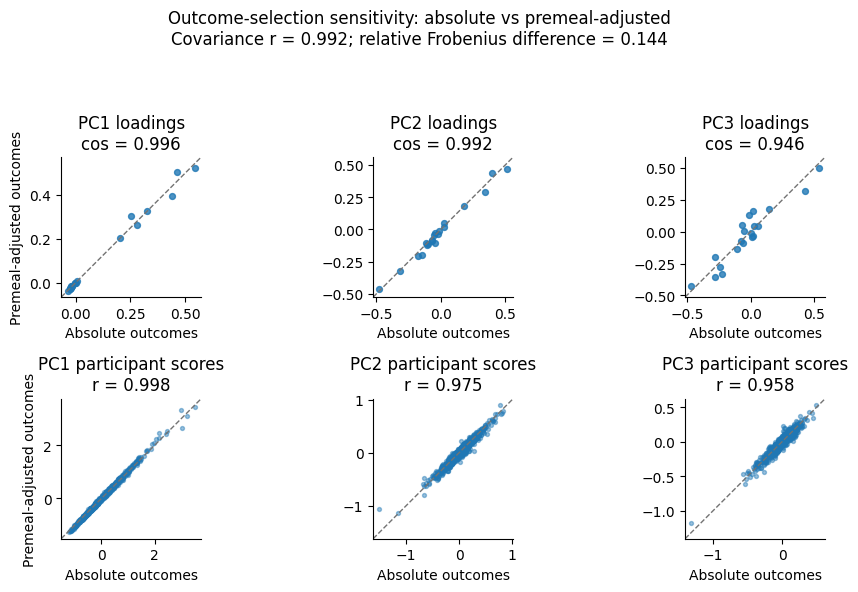

In [10]:
## 6. Save compact analysis outputs

#tables_to_save = {
#    "outcome_selection_dimensionality.csv": dimensionality_table,
#    "outcome_selection_spectrum.csv": spectrum_table,
#    "outcome_selection_subspace.csv": subspace_table,
#    "outcome_selection_geometry.csv": geometry_summary.rename_axis("metric").reset_index(),
#    "outcome_selection_coordinate_sd.csv": coordinate_table,
#    "outcome_selection_pc_axis_matching.csv": pc_axis_matching,
#    "outcome_selection_loadings_pc1_pc2.csv": loading_table.rename_axis("coordinate").reset_index(),
#    "outcome_selection_participant_agreement.csv": participant_agreement,
#    "outcome_selection_participant_scores.csv": participant_scores,
#    "outcome_selection_schur_summary.csv": schur_summary.rename_axis("specification").reset_index(),
#    "outcome_selection_schur_axis_matching.csv": schur_axis_matching,
#    "outcome_selection_schur_subspace.csv": schur_subspace_table,
#    "outcome_selection_schur_pc1_loadings.csv": schur_loading_table.rename_axis("coordinate").reset_index(),
#}
#for filename, table in tables_to_save.items():
#    table.to_csv(RESULTS_DIR / filename, index=False)


def plot_outcome_selection_sensitivity(comparison, n_components=3, save_path=None):
    """Plot aligned loading vectors and participant scores for leading PCs."""
    axis_summary = comparison["axis_matching"].set_index("reference_pc")
    reference_loadings = comparison["reference_loadings"]
    aligned_loadings = comparison["alternative_loadings_aligned"]
    scores = comparison["participant_scores"]
    n_components = min(n_components, reference_loadings.shape[1])
    fig, axes = plt.subplots(
        2, n_components, figsize=(3.2 * n_components, 6.0), squeeze=False
    )

    def add_identity_line(axis, x, y):
        finite = np.isfinite(x) & np.isfinite(y)
        low = min(np.min(x[finite]), np.min(y[finite]))
        high = max(np.max(x[finite]), np.max(y[finite]))
        padding = 0.05 * (high - low) if high > low else 1.0
        limits = (low - padding, high + padding)
        axis.plot(limits, limits, ls="--", lw=1, color="0.45")
        axis.set_xlim(limits)
        axis.set_ylim(limits)
        axis.set_aspect("equal", adjustable="box")

    for axis_index in range(n_components):
        pc = f"PC{axis_index + 1}"
        loading_absolute = reference_loadings[pc].to_numpy(float)
        loading_delta = aligned_loadings[pc].to_numpy(float)
        axes[0, axis_index].scatter(
            loading_absolute, loading_delta, s=18, alpha=0.8
        )
        add_identity_line(axes[0, axis_index], loading_absolute, loading_delta)
        axes[0, axis_index].set_title(
            f"{pc} loadings\ncos = "
            f"{axis_summary.loc[pc, 'absolute_loading_cosine']:.3f}"
        )
        axes[0, axis_index].set_xlabel("Absolute outcomes")
        if axis_index == 0:
            axes[0, axis_index].set_ylabel("Premeal-adjusted outcomes")

        score_absolute = scores[f"{pc}_original"].to_numpy(float)
        score_delta = scores[f"{pc}_delta_aligned"].to_numpy(float)
        score_r = np.corrcoef(score_absolute, score_delta)[0, 1]
        axes[1, axis_index].scatter(
            score_absolute, score_delta, s=8, alpha=0.45
        )
        add_identity_line(axes[1, axis_index], score_absolute, score_delta)
        axes[1, axis_index].set_title(
            f"{pc} participant scores\nr = {score_r:.3f}"
        )
        axes[1, axis_index].set_xlabel("Absolute outcomes")
        if axis_index == 0:
            axes[1, axis_index].set_ylabel("Premeal-adjusted outcomes")

    geometry = comparison["geometry_summary"]
    fig.suptitle(
        "Outcome-selection sensitivity: absolute vs premeal-adjusted\n"
        f"Covariance r = {geometry['covariance_upper_triangle_r']:.3f}; "
        f"relative Frobenius difference = "
        f"{geometry['covariance_relative_frobenius']:.3f}",
        fontsize=12,
    )
    for axis in axes.flat:
        sns.despine(ax=axis)
    fig.tight_layout(rect=(0, 0, 1, 0.92))

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, format="svg", bbox_inches="tight")
    return fig


sensitivity_figure = plot_outcome_selection_sensitivity(
    sensitivity_comparison,
    n_components=3,
    save_path=None#FIGURES_DIR / "outcome_selection_sensitivity.svg",
)
plt.show()



## 7. Interpretation

Do not infer invariance from a single coefficient. Interpret the covariance-scale and correlation-geometry diagnostics together with leading-subspace cosines, matched-axis loadings, participant-score ICCs/quartiles, and the Schur-complement results. Near-perfect values across these complementary checks support robustness to outcome selection; discrepancies identify whether the change is mainly scale, axis rotation, participant ranking, or conditional slope structure.
